# 📈 Modelo SARIMAX — Pronóstico con Variables Exógenas

**Componente de Tesis: Modelo Econométrico con Regresores Exógenos**

Extiende el modelo SARIMA incorporando variables macroeconómicas como regresores
exógenos: IPC (inflación), variación del Salario Mínimo y UPC.

**Hipótesis:** La inclusión de variables macro mejora la capacidad predictiva,
reduciendo el AIC/BIC y el MAPE respecto al SARIMA puro.

---

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from utils import cargar_datos, agregar_mensual, calcular_metricas, formato_pesos

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


## 1. Preparación de Datos con Variables Exógenas

In [2]:
# 1. Reconstrucción robusta de la serie mensual (asegurando 2021-2025)
df = cargar_datos(DATA_FILE)
df_mensual = agregar_mensual(df)

# Mapear variables macro usando el diccionario de config
df_mensual['Año'] = df_mensual.index.year
for var in ['IPC', 'Salario_Minimo']:
    df_mensual[var] = df_mensual['Año'].map(lambda y: MACRO_DATA.get(y, {}).get(var, np.nan))
    df_mensual[f'{var}_Lag1'] = df_mensual[var].shift(1)

# Rellenar 2021 si hay NaNs
df_mensual.fillna(method='bfill', inplace=True)
df_mensual.dropna(inplace=True)

# Variables exógenas
exog_cols = ['IPC_Lag1', 'Salario_Minimo_Lag1']

# Split Train/Test
train = df_mensual.loc[:TRAIN_END]
test = df_mensual.loc[TEST_START:]

y_train = train['Recaudo_Neto']
y_test = test['Recaudo_Neto']
X_train = train[exog_cols]
X_test = test[exog_cols]

print(f'📊 Train: {len(train)} meses | Test: {len(test)} meses')
print(f'📊 Rango: {train.index.min().date()} a {train.index.max().date()}')
print(f'📊 Variables exógenas: {exog_cols}')

Aviso: 22 registros con ValorRecaudo < 0 (anulaciones fiscales, se conservan).
Datos cargados: 141,753 filas × 15 columnas
   Periodo: 2022-01-03 a 2025-12-31
✅ Serie mensual: 48 observaciones
📊 Train: 45 meses | Test: 3 meses
📊 Rango: 2022-01-01 a 2025-09-01
📊 Variables exógenas: ['IPC_Lag1', 'Salario_Minimo_Lag1']


## 2. Ajuste del Modelo SARIMAX

In [3]:
# Simplificamos el modelo para series cortas (evita ValueError en diagnósticos)
# Usamos el orden exitoso del SARIMA puro: (1,0,0)x(0,1,0,12) + Variables Exógenas
order = (1, 0, 0)
seasonal_order = (0, 1, 0, ESTACIONALIDAD)

modelo_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarimax = modelo_sarimax.fit(disp=False, maxiter=500)

print(resultado_sarimax.summary())
print(f'\n📊 AIC: {resultado_sarimax.aic:.2f} | BIC: {resultado_sarimax.bic:.2f}')

                                     SARIMAX Results                                      
Dep. Variable:                       Recaudo_Neto   No. Observations:                   45
Model:             SARIMAX(1, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -821.700
Date:                            Mon, 02 Mar 2026   AIC                           1651.401
Time:                                    10:37:56   BIC                           1657.263
Sample:                                01-01-2022   HQIC                          1653.344
                                     - 09-01-2025                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
IPC_Lag1            -4.624e+09    1.1e-12  -4.21e+21      0.000   -4.62e+09   -4.62e+09
Salario_

## 3. Diagnóstico de Residuos

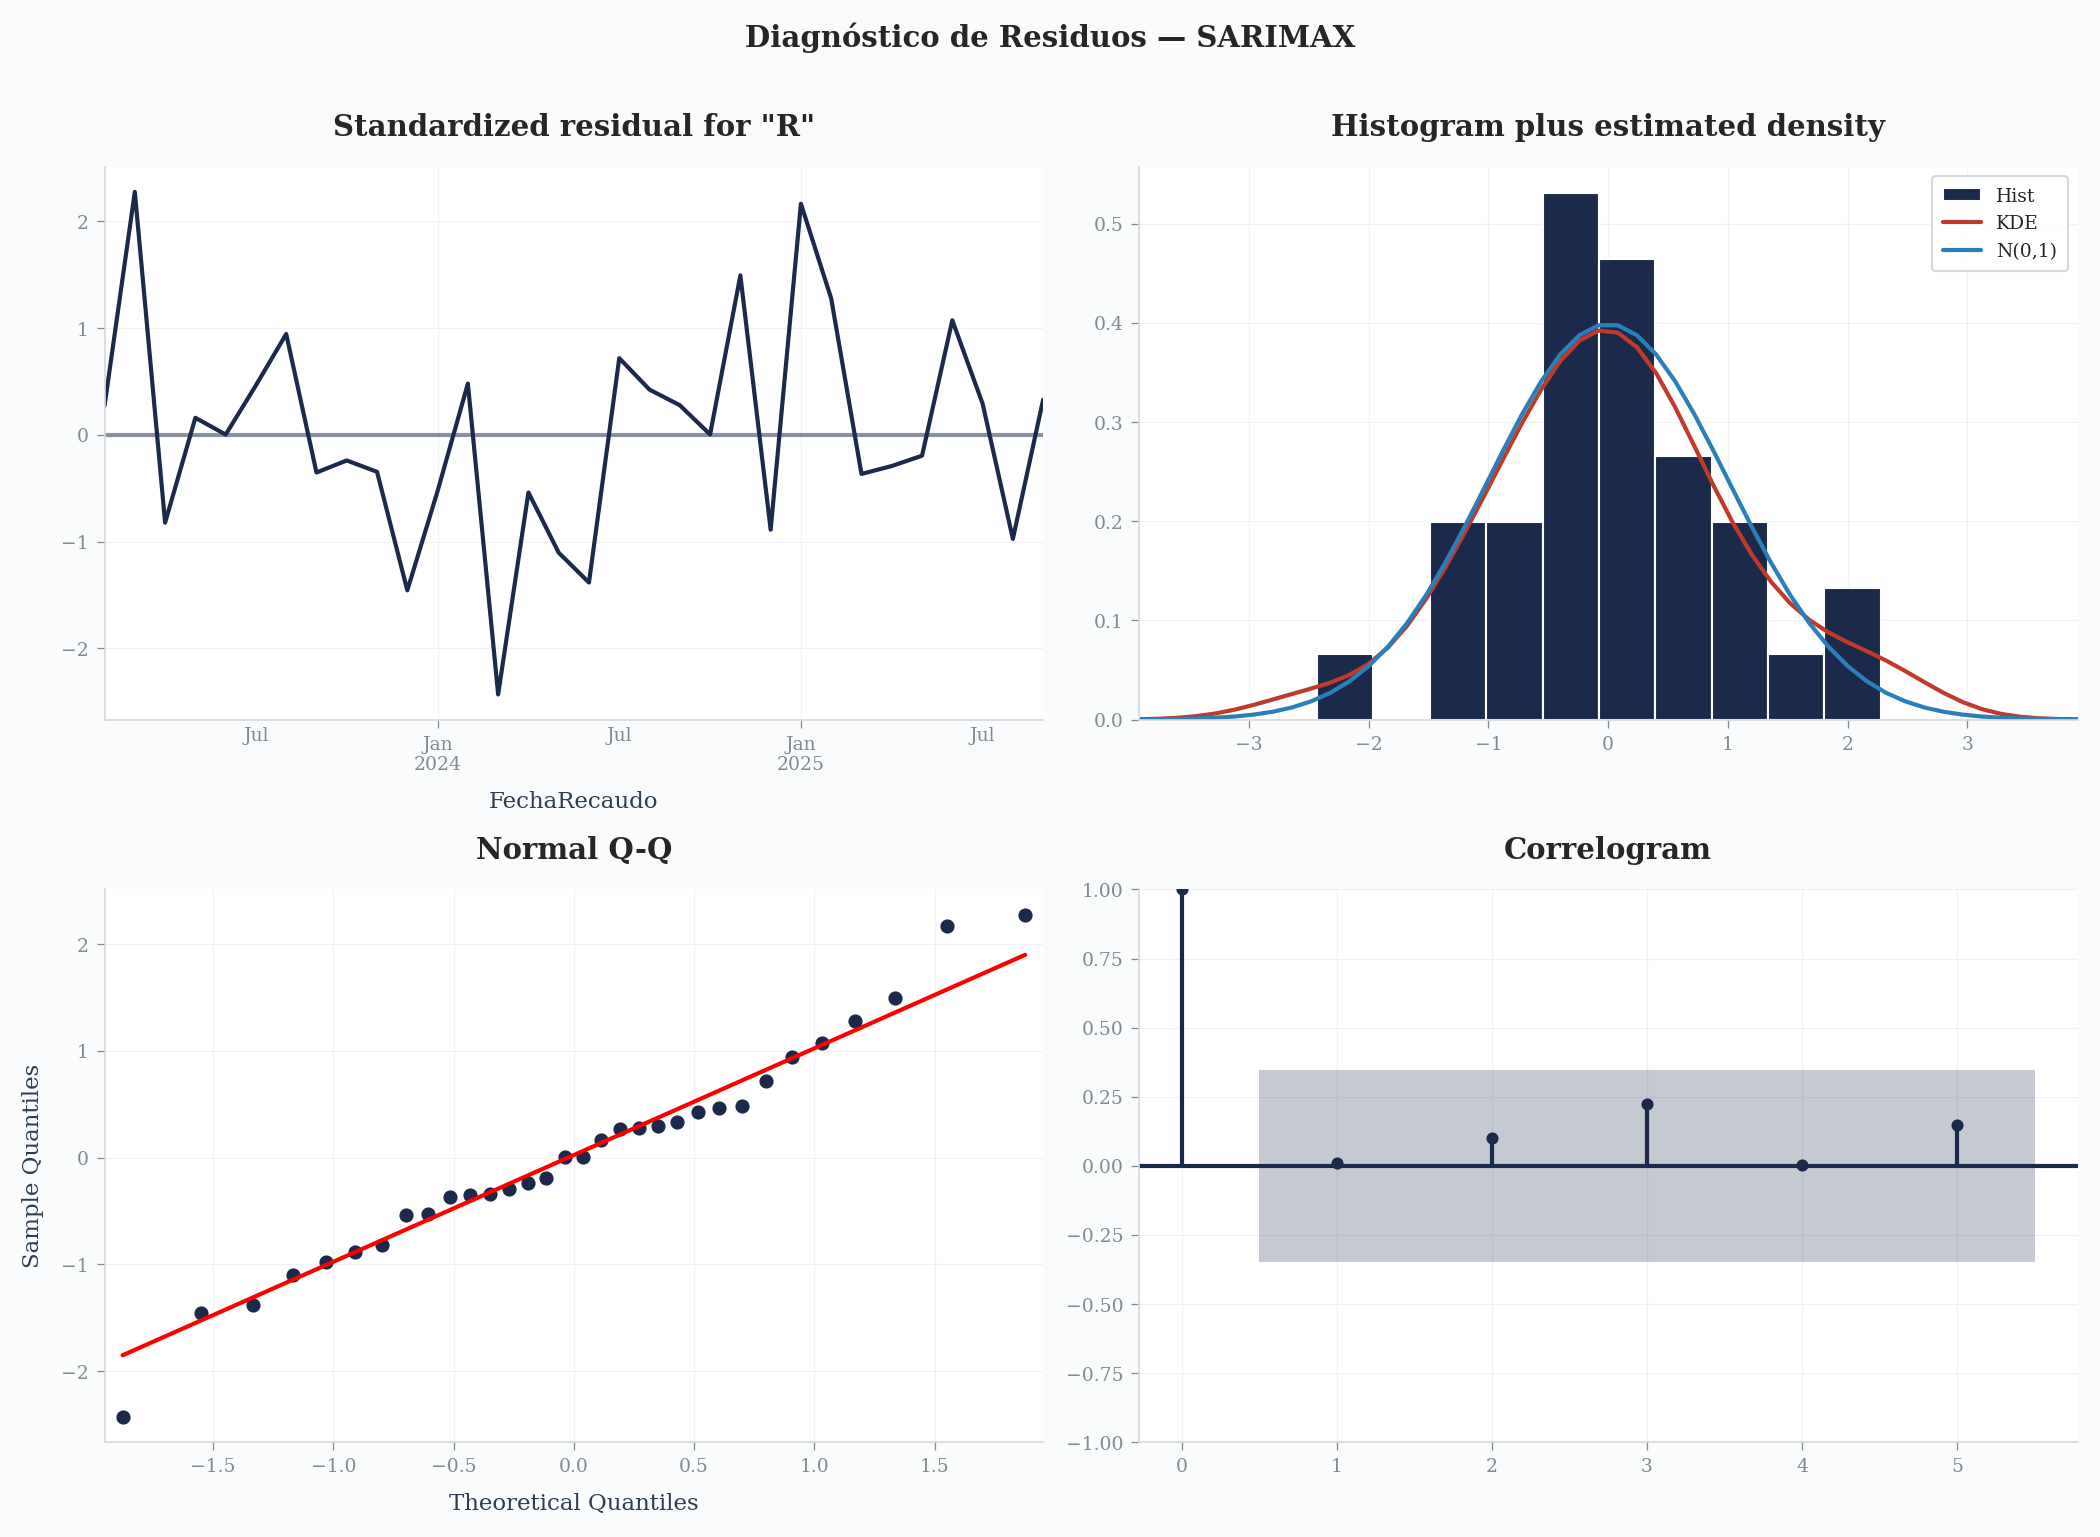


📊 Test Ljung-Box:
       lb_stat     lb_pvalue
12  160.727476  3.733510e-28


In [4]:
try:
    # Reducimos lags a 5 para mayor compatibilidad con series cortas
    fig = resultado_sarimax.plot_diagnostics(figsize=(14, 10), lags=5)
    fig.suptitle('Diagnóstico de Residuos — SARIMAX', fontweight='bold', fontsize=14, y=1.01)
    plt.tight_layout()
    fig.savefig(OUTPUTS_FIGURES / '05_sarimax_diagnostico.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'⚠️ No se pudo generar el plot_diagnostics automático: {e}')

lb_test = acorr_ljungbox(resultado_sarimax.resid, lags=[min(12, len(resultado_sarimax.resid)-1)], return_df=True)
print('\n📊 Test Ljung-Box:')
print(lb_test)

## 4. Pronóstico y Comparación con SARIMA


📈 Métricas — SARIMAX
   RMSE:  42,501,129,492
   MAE:   39,128,751,277
   MAPE:  13.73%
   R²:    -0.9262

📊 MÉTRICAS DE EVALUACIÓN SARIMAX (TEST - 3 meses)
--------------------------------------------------
  MAPE: 13.73%
  RMSE: $42.50MM
   MAE: $39.13MM

📈 Métricas — SARIMA
   RMSE:  43,938,464,144
   MAE:   40,888,323,884
   MAPE:  14.47%
   R²:    -1.0587


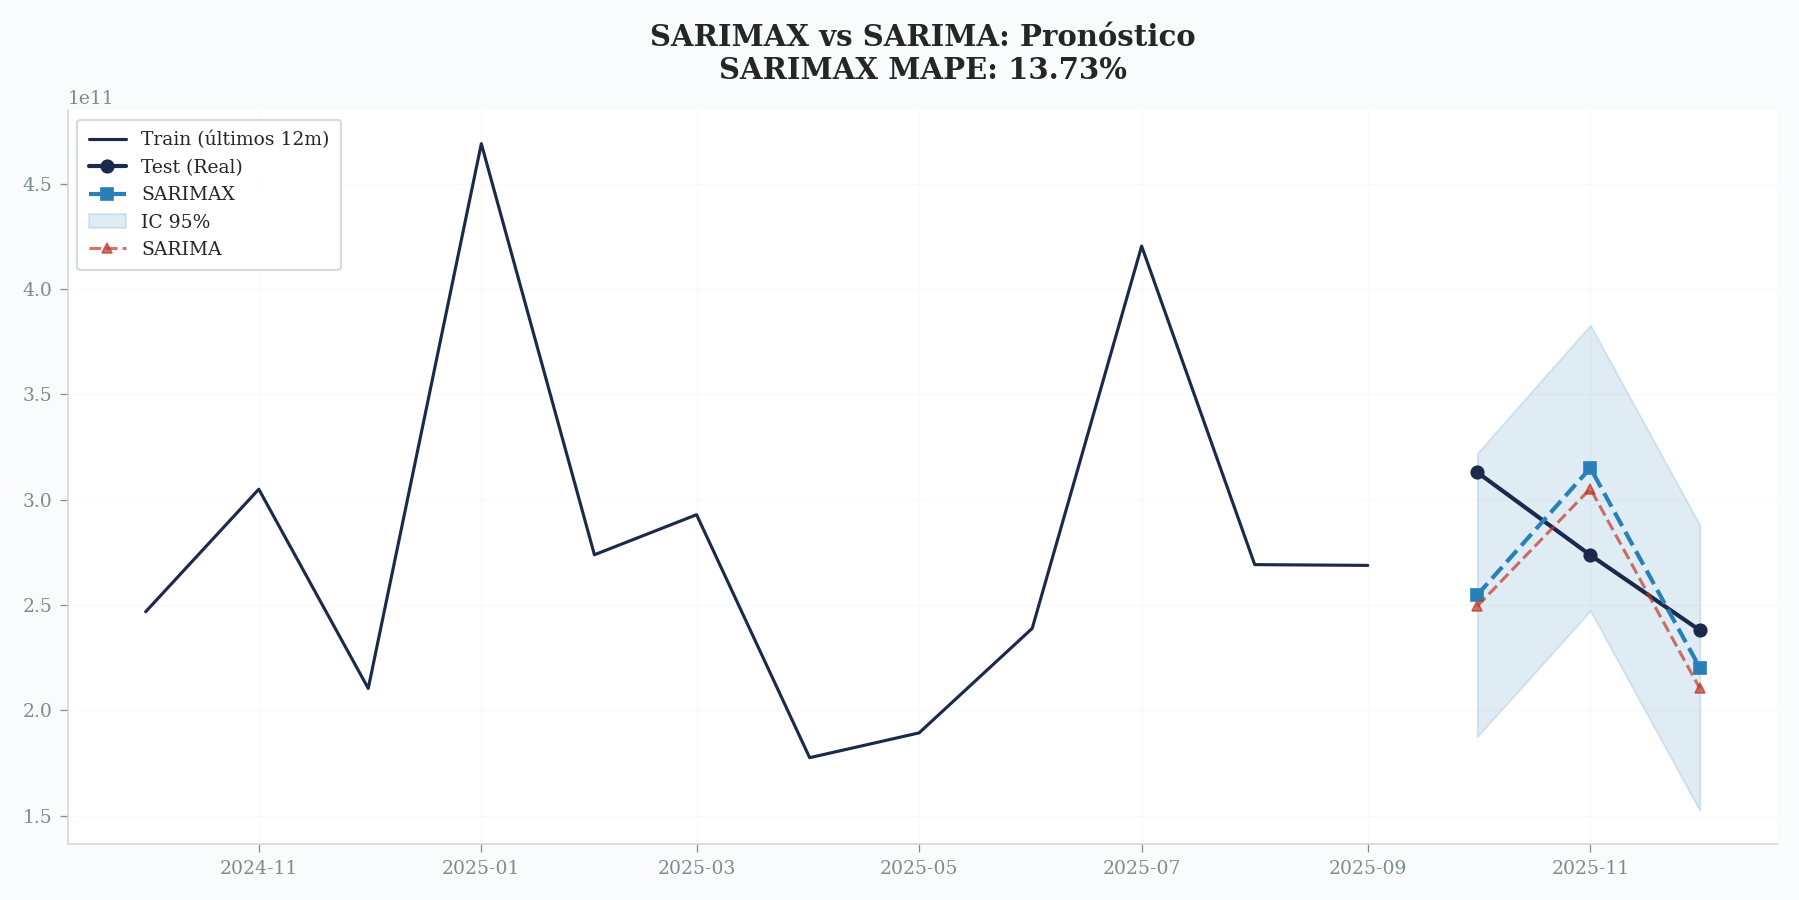

In [5]:
# Pronóstico
forecast_result = resultado_sarimax.get_forecast(steps=len(test), exog=X_test)
y_pred_sarimax = forecast_result.predicted_mean
y_pred_sarimax.index = test.index
ci = forecast_result.conf_int(alpha=0.05)
ci.index = test.index

# Métricas SARIMAX
metricas_sarimax = calcular_metricas(y_test, y_pred_sarimax, 'SARIMAX')

print(f"\n📊 MÉTRICAS DE EVALUACIÓN SARIMAX (TEST - {len(test)} meses)")
print("-" * 50)
print(f"  MAPE: {metricas_sarimax['MAPE (%)']:.2f}%")
print(f"  RMSE: {formato_pesos(metricas_sarimax['RMSE'])}")
print(f"   MAE: {formato_pesos(metricas_sarimax['MAE'])}")

# Cargar métricas SARIMA para comparar
try:
    df_sarima = pd.read_csv(OUTPUTS_FORECASTS / 'sarima_forecast.csv', index_col=0, parse_dates=True)
    metricas_sarima_prev = calcular_metricas(y_test, df_sarima['Pronostico_SARIMA'], 'SARIMA')
except FileNotFoundError:
    metricas_sarima_prev = None

# Gráfico comparativo
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)
ax.plot(y_train.index[-12:], y_train.values[-12:], color=COLORES['real'], linewidth=1.5, label='Train (últimos 12m)')
ax.plot(y_test.index, y_test.values, 'o-', color=COLORES['real'], linewidth=2, markersize=6, label='Test (Real)')
ax.plot(y_pred_sarimax.index, y_pred_sarimax.values, 's--', color=COLORES['sarimax'], 
        linewidth=2, markersize=6, label='SARIMAX')
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color=COLORES['sarimax'], alpha=0.15, label='IC 95%')

if metricas_sarima_prev:
    ax.plot(df_sarima.index, df_sarima['Pronostico_SARIMA'], '^--', color=COLORES['sarima'], 
            linewidth=1.5, markersize=5, label='SARIMA', alpha=0.7)

ax.set_title(f'SARIMAX vs SARIMA: Pronóstico\nSARIMAX MAPE: {metricas_sarimax["MAPE (%)"]:.2f}%', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '05_sarimax_pronostico.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Significancia de variables exógenas
print('\n📊 SIGNIFICANCIA DE VARIABLES EXÓGENAS')
print('-' * 50)
for var in exog_cols:
    pval = resultado_sarimax.pvalues.get(var, np.nan)
    coef = resultado_sarimax.params.get(var, np.nan)
    sig = '✅ Significativa' if pval < 0.05 else '⚠️ No significativa'
    print(f'   {var:>20}: coef={coef:+.4e}, p-valor={pval:.4f} → {sig}')

# Exportar
df_forecast = pd.DataFrame({'Pronostico_SARIMAX': y_pred_sarimax.values, 'Real': y_test.values}, index=test.index)
df_forecast.index.name = 'Fecha'
df_forecast.to_csv(OUTPUTS_FORECASTS / 'sarimax_forecast.csv')
pd.DataFrame([metricas_sarimax]).to_csv(OUTPUTS_REPORTS / 'sarimax_metricas.csv', index=False)

print('\n' + '='*60)
print('  ✅ SARIMAX COMPLETADO — Proceder con 06_Prophet.ipynb')
print('='*60)


📊 SIGNIFICANCIA DE VARIABLES EXÓGENAS
--------------------------------------------------
               IPC_Lag1: coef=-4.6240e+09, p-valor=0.0000 → ✅ Significativa
    Salario_Minimo_Lag1: coef=-1.4851e+09, p-valor=0.0000 → ✅ Significativa

  ✅ SARIMAX COMPLETADO — Proceder con 06_Prophet.ipynb
